In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
risk_df = pd.read_csv("../data/project_risk_raw_dataset.csv")

print("Dataset shape:", risk_df.shape)
risk_df.head()

Dataset shape: (4000, 51)


,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [3]:
X = risk_df.drop(columns=["Project_ID", "Risk_Level"])
y = risk_df["Risk_Level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4000, 49)
y shape: (4000,)


In [4]:
risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Critical": 3
}

y_encoded = y.map(risk_mapping)

print(y_encoded.value_counts().sort_index())

Risk_Level
0     806
1    1396
2    1036
3     762
Name: count, dtype: int64


0 = Low
1 = Medium
2 = High
3 = Critical

In [5]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 25
Categorical features: 24


In [6]:
print("\nNumerical:")
print(numerical_features)

print("\nCategorical:")
print(categorical_features)


Numerical:
['Team_Size', 'Project_Budget_USD', 'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count', 'Past_Similar_Projects', 'External_Dependencies_Count', 'Change_Request_Frequency', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Historical_Risk_Incidents', 'Communication_Frequency', 'Geographical_Distribution', 'Schedule_Pressure', 'Budget_Utilization_Rate', 'Market_Volatility', 'Integration_Complexity', 'Resource_Availability', 'Organizational_Change_Frequency', 'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate', 'Technical_Debt_Level', 'Project_Start_Month', 'Current_Phase_Duration_Months', 'Seasonal_Risk_Factor']

Categorical:
['Project_Type', 'Methodology_Used', 'Team_Experience_Level', 'Project_Phase', 'Requirement_Stability', 'Regulatory_Compliance_Level', 'Technology_Familiarity', 'Stakeholder_Engagement_Level', 'Executive_Sponsorship', 'Funding_Source', 'Priority_Level', 'Project_Manager_Experience', 'Org_Process_Maturity', 'Data_Security_

In [9]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2800, 49)
Validation: (600, 49)
Test: (600, 49)


In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train processed:", X_train_processed.shape)
print("Validation processed:", X_val_processed.shape)
print("Test processed:", X_test_processed.shape)

Train processed: (2800, 120)
Validation processed: (600, 120)
Test processed: (600, 120)


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Input features:", X_train_processed.shape[1])

TensorFlow version: 2.21.0
Input features: 120


In [13]:
model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),

    layers.Dense(4, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,724 (104.39 KB)

 Trainable params: 26,340 (102.89 KB)

 Non-trainable params: 384 (1.50 KB)

In [14]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3196 - loss: 1.5831 - val_accuracy: 0.3550 - val_loss: 1.3003
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4143 - loss: 1.2569 - val_accuracy: 0.4517 - val_loss: 1.1553
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5143 - loss: 1.0584 - val_accuracy: 0.5467 - val_loss: 0.9679
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5854 - loss: 0.9130 - val_accuracy: 0.6183 - val_loss: 0.8284
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6421 - loss: 0.7997 - val_accuracy: 0.6667 - val_loss: 0.7356
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6750 - loss: 0.7342 - val_accuracy: 0.6783 - val_loss: 0.7060
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6861 - loss: 0.6903 - val_accuracy: 0.6883 - val_loss: 0.6741
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7064 - loss: 0.6711 - val_accuracy: 0.693

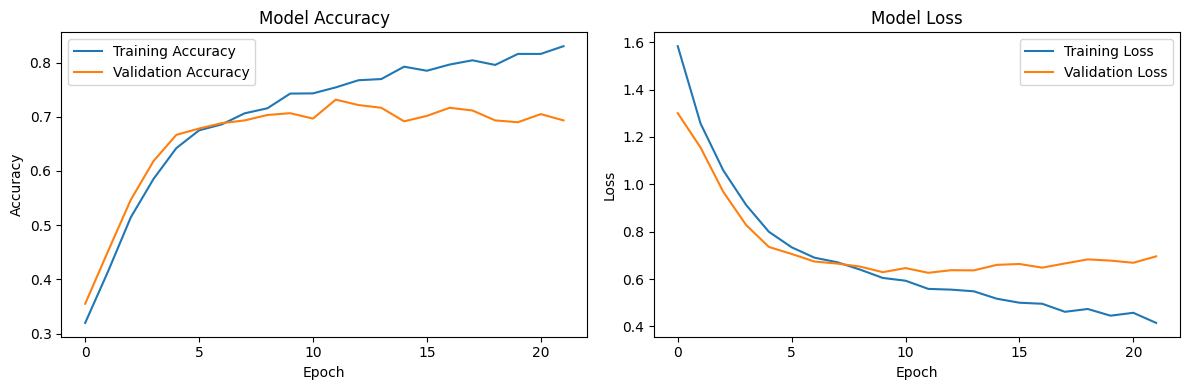

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6351
Test Accuracy: 0.7050


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model.predict(X_test_processed)
y_pred = np.argmax(y_prob, axis=1)

class_names = ["Low", "Medium", "High", "Critical"]

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

         Low       0.78      0.89      0.83       121
      Medium       0.74      0.68      0.71       210
        High       0.60      0.54      0.57       155
    Critical       0.69      0.77      0.73       114

    accuracy                           0.70       600
   macro avg       0.70      0.72      0.71       600
weighted avg       0.70      0.70      0.70       600



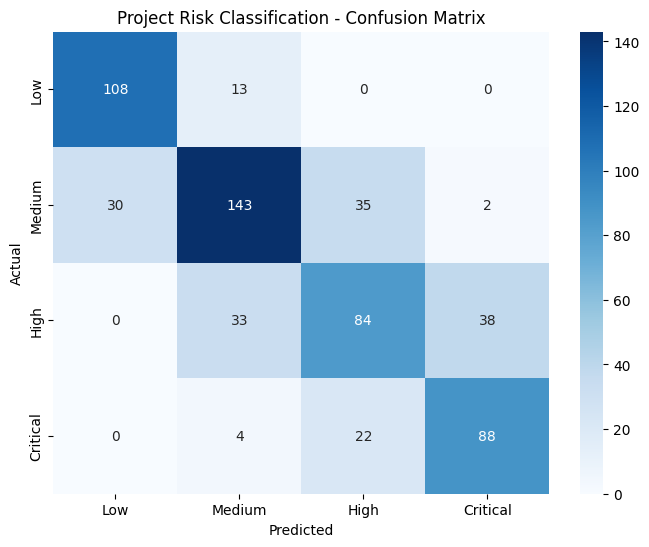

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Project Risk Classification - Confusion Matrix")

plt.show()

In [22]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(1.2411347517730495), np.int64(1): np.float64(0.7164790174002047), np.int64(2): np.float64(0.9655172413793104), np.int64(3): np.float64(1.3108614232209739)}


In [23]:
model_v2 = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),

    layers.Dense(4, activation="softmax")
])

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
early_stopping_v2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [25]:
history_v2 = model_v2.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping_v2, reduce_lr],
    verbose=1
)

Epoch 1/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.2993 - loss: 1.4676 - val_accuracy: 0.3750 - val_loss: 1.2631 - learning_rate: 5.0000e-04
Epoch 2/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4293 - loss: 1.1632 - val_accuracy: 0.4333 - val_loss: 1.1344 - learning_rate: 5.0000e-04
Epoch 3/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4832 - loss: 1.0271 - val_accuracy: 0.5067 - val_loss: 1.0188 - learning_rate: 5.0000e-04
Epoch 4/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5514 - loss: 0.8993 - val_accuracy: 0.5533 - val_loss: 0.9248 - learning_rate: 5.0000e-04
Epoch 5/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5857 - loss: 0.8318 - val_accuracy: 0.6033 - val_loss: 0.8539 - learning_rate: 5.0000e-04
Epoch 6/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6421 - loss: 0.7255 - val_accuracy: 0.6100 - val_loss: 0.8175 - learning_rate: 5.0000e-04
Epoch 7/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.64

In [26]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

y_prob_v2 = model_v2.predict(X_test_processed)
y_pred_v2 = np.argmax(y_prob_v2, axis=1)

print(f"V2 Test Accuracy: {test_accuracy_v2:.4f}")

print(classification_report(
    y_test,
    y_pred_v2,
    target_names=["Low", "Medium", "High", "Critical"]
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
V2 Test Accuracy: 0.7033
              precision    recall  f1-score   support

         Low       0.78      0.90      0.84       121
      Medium       0.78      0.67      0.72       210
        High       0.57      0.59      0.58       155
    Critical       0.68      0.71      0.70       114

    accuracy                           0.70       600
   macro avg       0.70      0.72      0.71       600
weighted avg       0.71      0.70      0.70       600



In [27]:
model_v3 = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),

    layers.Dense(4, activation="softmax")
])

model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
early_stopping_v3 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr_v3 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [29]:
history_v3 = model_v3.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping_v3, reduce_lr_v3],
    verbose=1
)

Epoch 1/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2957 - loss: 1.6475 - val_accuracy: 0.3233 - val_loss: 1.3228 - learning_rate: 5.0000e-04
Epoch 2/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3729 - loss: 1.3392 - val_accuracy: 0.3800 - val_loss: 1.2488 - learning_rate: 5.0000e-04
Epoch 3/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4443 - loss: 1.1928 - val_accuracy: 0.4417 - val_loss: 1.1503 - learning_rate: 5.0000e-04
Epoch 4/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5093 - loss: 1.0518 - val_accuracy: 0.5117 - val_loss: 1.0436 - learning_rate: 5.0000e-04
Epoch 5/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5657 - loss: 0.9646 - val_accuracy: 0.5767 - val_loss: 0.9433 - learning_rate: 5.0000e-04
Epoch 6/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6089 - loss: 0.8693 - val_accuracy: 0.6000 - val_loss: 0.8704 - learning_rate: 5.0000e-04
Epoch 7/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 

In [30]:
test_loss_v3, test_accuracy_v3 = model_v3.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

y_prob_v3 = model_v3.predict(X_test_processed)
y_pred_v3 = np.argmax(y_prob_v3, axis=1)

print(f"V3 Test Accuracy: {test_accuracy_v3:.4f}")

print(classification_report(
    y_test,
    y_pred_v3,
    target_names=["Low", "Medium", "High", "Critical"]
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
V3 Test Accuracy: 0.7267
              precision    recall  f1-score   support

         Low       0.81      0.90      0.85       121
      Medium       0.77      0.70      0.73       210
        High       0.60      0.64      0.62       155
    Critical       0.75      0.72      0.73       114

    accuracy                           0.73       600
   macro avg       0.73      0.74      0.73       600
weighted avg       0.73      0.73      0.73       600



In [31]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

# Save final deep learning model
model_v3.save("../models/project_risk_model.keras")

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Final model and preprocessor saved successfully!")

Final model and preprocessor saved successfully!


# Model Optimization - Feature Importance

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

print("Random Forest diagnostic model trained!")

Random Forest diagnostic model trained!


In [33]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print(feature_names[:20])

Number of processed features: 120
['num__Team_Size' 'num__Project_Budget_USD'
 'num__Estimated_Timeline_Months' 'num__Complexity_Score'
 'num__Stakeholder_Count' 'num__Past_Similar_Projects'
 'num__External_Dependencies_Count' 'num__Change_Request_Frequency'
 'num__Team_Turnover_Rate' 'num__Vendor_Reliability_Score'
 'num__Historical_Risk_Incidents' 'num__Communication_Frequency'
 'num__Geographical_Distribution' 'num__Schedule_Pressure'
 'num__Budget_Utilization_Rate' 'num__Market_Volatility'
 'num__Integration_Complexity' 'num__Resource_Availability'
 'num__Organizational_Change_Frequency'
 'num__Cross_Functional_Dependencies']


In [34]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(30)

,Feature,Importance
3,num__Complexity_Score,0.044241
8,num__Team_Turnover_Rate,0.031966
20,num__Previous_Delivery_Success_Rate,0.027545
11,num__Communication_Frequency,0.027060
16,num__Integration_Complexity,0.026703
15,num__Market_Volatility,0.025945
1,num__Project_Budget_USD,0.025932
2,num__Estimated_Timeline_Months,0.025927
18,num__Organizational_Change_Frequency,0.025491
17,num__Resource_Availability,0.024547


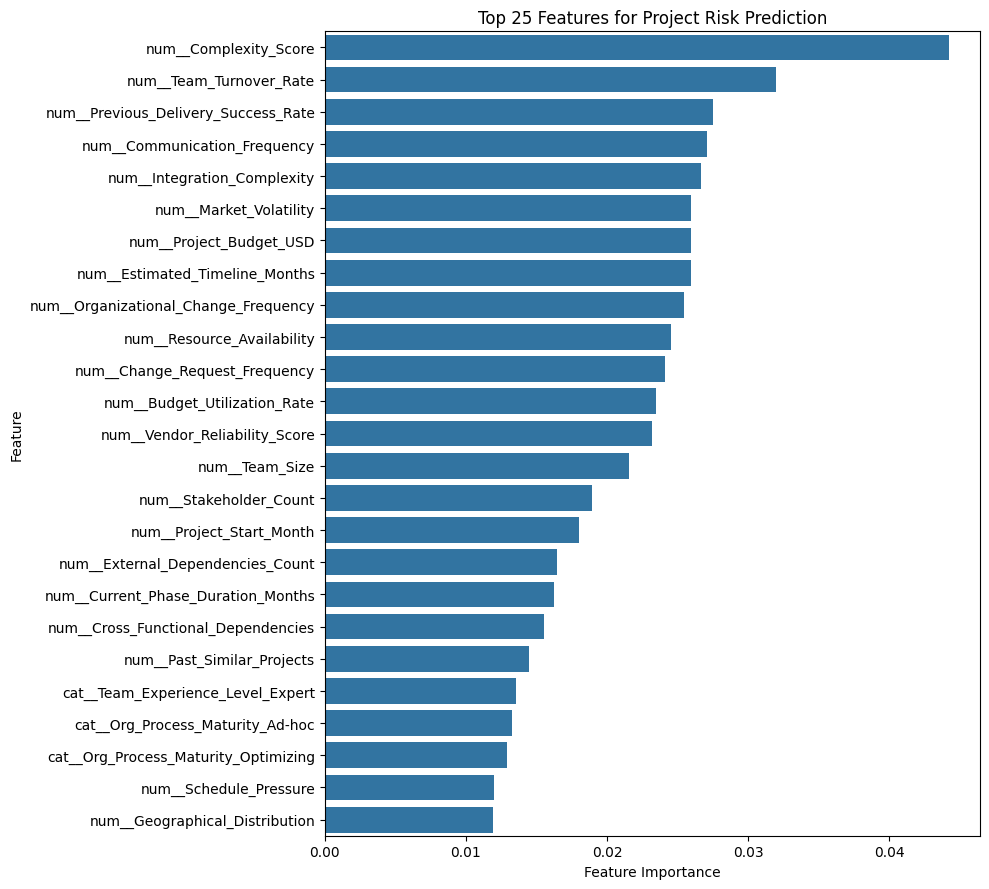

In [35]:
top_features = feature_importance.head(25)

plt.figure(figsize=(10, 9))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 25 Features for Project Risk Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [36]:
feature_importance["Cumulative_Importance"] = (
    feature_importance["Importance"].cumsum()
)

feature_importance.head(40)

,Feature,Importance,Cumulative_Importance
3,num__Complexity_Score,0.044241,0.044241
8,num__Team_Turnover_Rate,0.031966,0.076207
20,num__Previous_Delivery_Success_Rate,0.027545,0.103752
11,num__Communication_Frequency,0.027060,0.130812
16,num__Integration_Complexity,0.026703,0.157515
15,num__Market_Volatility,0.025945,0.183460
1,num__Project_Budget_USD,0.025932,0.209392
2,num__Estimated_Timeline_Months,0.025927,0.235319
18,num__Organizational_Change_Frequency,0.025491,0.260810
17,num__Resource_Availability,0.024547,0.285357


In [37]:
for threshold in [0.80, 0.90, 0.95]:
    count = (
        feature_importance["Cumulative_Importance"] <= threshold
    ).sum() + 1

    print(
        f"Features needed for {threshold:.0%} importance: {count}"
    )

Features needed for 80% importance: 68
Features needed for 90% importance: 91
Features needed for 95% importance: 104


In [38]:
feature_importance.tail(20)

,Feature,Importance,Cumulative_Importance
34,cat__Methodology_Used_Scrum,0.003756,0.941572
58,cat__Stakeholder_Engagement_Level_Medium,0.003748,0.945320
112,cat__Team_Colocation_Fully Colocated,0.003735,0.949055
66,cat__Funding_Source_Mixed,0.003657,0.952712
90,cat__Tech_Environment_Stability_Modern/Stable,0.003530,0.956242
117,cat__Documentation_Quality_Excellent,0.003509,0.959751
43,cat__Project_Phase_Monitoring,0.003445,0.963196
93,cat__Contract_Type_Hybrid,0.003339,0.966536
91,cat__Contract_Type_Cost-Plus,0.003330,0.969866
27,cat__Project_Type_IT,0.003224,0.973090


In [39]:
from sklearn.metrics import accuracy_score, classification_report

rf_val_pred = rf.predict(X_val_processed)

rf_val_accuracy = accuracy_score(
    y_val,
    rf_val_pred
)

print(f"Random Forest Validation Accuracy: {rf_val_accuracy:.4f}")

print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=["Low", "Medium", "High", "Critical"]
    )
)

Random Forest Validation Accuracy: 0.5200
              precision    recall  f1-score   support

         Low       0.71      0.40      0.52       121
      Medium       0.49      0.76      0.60       209
        High       0.41      0.29      0.34       156
    Critical       0.59      0.51      0.55       114

    accuracy                           0.52       600
   macro avg       0.55      0.49      0.50       600
weighted avg       0.54      0.52      0.51       600



# V4 - Risk-Focused Feature Engineering

In [40]:
X_v4 = risk_df.drop(columns=["Project_ID", "Risk_Level"]).copy()
y_v4 = y_encoded.copy()

print(X_v4.shape)

(4000, 49)


In [41]:
# Risk-focused engineered features

X_v4["Delivery_Risk_Index"] = (
    0.25 * X_v4["Complexity_Score"] +
    0.20 * X_v4["Schedule_Pressure"] +
    0.15 * X_v4["Team_Turnover_Rate"] +
    0.15 * X_v4["Change_Request_Frequency"] +
    0.15 * X_v4["Historical_Risk_Incidents"] +
    0.10 * X_v4["Technical_Debt_Level"]
)

X_v4["Execution_Strength_Index"] = (
    0.25 * X_v4["Previous_Delivery_Success_Rate"] +
    0.20 * X_v4["Resource_Availability"] +
    0.20 * X_v4["Vendor_Reliability_Score"] +
    0.20 * X_v4["Budget_Utilization_Rate"] +
    0.15 * X_v4["Team_Size"]
)

X_v4["Pressure_Complexity_Interaction"] = (
    X_v4["Schedule_Pressure"] *
    X_v4["Complexity_Score"]
)

X_v4["Turnover_Change_Interaction"] = (
    X_v4["Team_Turnover_Rate"] *
    X_v4["Change_Request_Frequency"]
)

print("New V4 shape:", X_v4.shape)

New V4 shape: (4000, 53)


In [42]:
numerical_features_v4 = X_v4.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_v4 = X_v4.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", len(numerical_features_v4))
print("Categorical:", len(categorical_features_v4))

Numerical: 29
Categorical: 24


In [43]:
numerical_pipeline_v4 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_v4 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_v4 = ColumnTransformer([
    ("num", numerical_pipeline_v4, numerical_features_v4),
    ("cat", categorical_pipeline_v4, categorical_features_v4)
])

In [44]:
X_train_v4, X_temp_v4, y_train_v4, y_temp_v4 = train_test_split(
    X_v4,
    y_v4,
    test_size=0.30,
    random_state=42,
    stratify=y_v4
)

X_val_v4, X_test_v4, y_val_v4, y_test_v4 = train_test_split(
    X_temp_v4,
    y_temp_v4,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_v4
)

In [45]:
X_train_v4_processed = preprocessor_v4.fit_transform(X_train_v4)
X_val_v4_processed = preprocessor_v4.transform(X_val_v4)
X_test_v4_processed = preprocessor_v4.transform(X_test_v4)

print("Train:", X_train_v4_processed.shape)
print("Val:", X_val_v4_processed.shape)
print("Test:", X_test_v4_processed.shape)

Train: (2800, 124)
Val: (600, 124)
Test: (600, 124)


## V4 Deep Neural Network

In [46]:
model_v4 = keras.Sequential([
    layers.Input(shape=(X_train_v4_processed.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    layers.Dense(32, activation="relu"),

    layers.Dense(4, activation="softmax")
])

model_v4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,156 (301.39 KB)

 Trainable params: 76,260 (297.89 KB)

 Non-trainable params: 896 (3.50 KB)

In [47]:
early_stopping_v4 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr_v4 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [48]:
history_v4 = model_v4.fit(
    X_train_v4_processed,
    y_train_v4,

    validation_data=(
        X_val_v4_processed,
        y_val_v4
    ),

    epochs=150,
    batch_size=32,

    callbacks=[
        early_stopping_v4,
        reduce_lr_v4
    ],

    verbose=1
)

Epoch 1/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3346 - loss: 1.5860 - val_accuracy: 0.3100 - val_loss: 1.3338 - learning_rate: 5.0000e-04
Epoch 2/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4043 - loss: 1.2802 - val_accuracy: 0.3867 - val_loss: 1.2480 - learning_rate: 5.0000e-04
Epoch 3/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4839 - loss: 1.1242 - val_accuracy: 0.4550 - val_loss: 1.1198 - learning_rate: 5.0000e-04
Epoch 4/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5389 - loss: 1.0081 - val_accuracy: 0.5100 - val_loss: 0.9830 - learning_rate: 5.0000e-04
Epoch 5/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6043 - loss: 0.8899 - val_accuracy: 0.5750 - val_loss: 0.8787 - learning_rate: 5.0000e-04
Epoch 6/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6561 - loss: 0.7900 - val_accuracy: 0.6367 - val_loss: 0.7976 - learning_rate: 5.0000e-04
Epoch 7/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6882

In [49]:
best_epoch_v4 = np.argmax(history_v4.history["val_accuracy"]) + 1
best_val_accuracy_v4 = max(history_v4.history["val_accuracy"])

print("Best Epoch:", best_epoch_v4)
print(f"Best Validation Accuracy: {best_val_accuracy_v4:.2%}")

Best Epoch: 15
Best Validation Accuracy: 72.50%


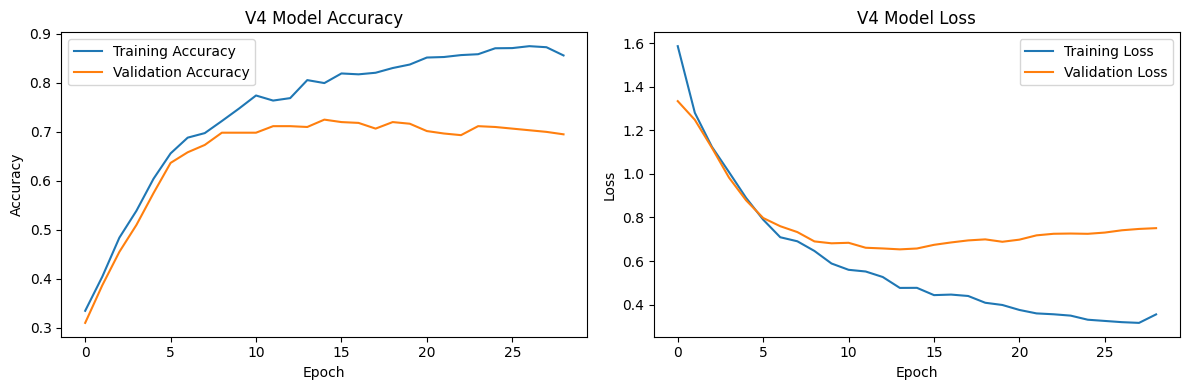

In [50]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(
    history_v4.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_v4.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("V4 Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1, 2, 2)

plt.plot(
    history_v4.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_v4.history["val_loss"],
    label="Validation Loss"
)

plt.title("V4 Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import classification_report

y_val_prob_v4 = model_v4.predict(
    X_val_v4_processed,
    verbose=0
)

y_val_pred_v4 = np.argmax(
    y_val_prob_v4,
    axis=1
)

print(
    classification_report(
        y_val_v4,
        y_val_pred_v4,
        target_names=["Low", "Medium", "High", "Critical"]
    )
)

              precision    recall  f1-score   support

         Low       0.80      0.81      0.80       121
      Medium       0.72      0.72      0.72       209
        High       0.62      0.56      0.59       156
    Critical       0.71      0.80      0.75       114

    accuracy                           0.71       600
   macro avg       0.71      0.72      0.71       600
weighted avg       0.71      0.71      0.71       600



In [52]:
y_val_prob_v3 = model_v3.predict(
    X_val_processed,
    verbose=0
)

y_val_pred_v3 = np.argmax(
    y_val_prob_v3,
    axis=1
)

print("V3 VALIDATION RESULTS")

print(
    classification_report(
        y_val,
        y_val_pred_v3,
        target_names=["Low", "Medium", "High", "Critical"]
    )
)

V3 VALIDATION RESULTS
              precision    recall  f1-score   support

         Low       0.78      0.79      0.79       121
      Medium       0.73      0.74      0.74       209
        High       0.64      0.63      0.63       156
    Critical       0.75      0.75      0.75       114

    accuracy                           0.72       600
   macro avg       0.73      0.73      0.73       600
weighted avg       0.72      0.72      0.72       600



In [53]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_v3.save("../models/project_risk_model_v3.keras")

joblib.dump(
    preprocessor,
    "../models/preprocessor_v3.pkl"
)

print("Final V3 model saved successfully!")

Final V3 model saved successfully!


In [54]:
import tensorflow as tf
import os

os.makedirs("../models/project_risk_savedmodel", exist_ok=True)

tf.saved_model.save(
    model_v3,
    "../models/project_risk_savedmodel"
)

print("TensorFlow SavedModel exported successfully!")

INFO:tensorflow:Assets written to: ../models/project_risk_savedmodel\assets


INFO:tensorflow:Assets written to: ../models/project_risk_savedmodel\assets


TensorFlow SavedModel exported successfully!
